### Unsupervised Learning Methods and Dimensionality Reduction with PCA, All Weather Stations, 2010-2020, Scaled Data

#### Import Libraries, Assign Path, Import Datasets

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.pyplot import figure
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [4]:
path = r'/Users/artoe/Documents/DataAnalytics/Machine Learning With Python/Achievement 2/data'

In [5]:
weather = pd.read_csv(os.path.join(path, 'weather-prediction-processed.csv'), index_col = False)

In [6]:
pleasant = pd.read_csv(os.path.join(path, 'Pleasant_Weather.csv'), index_col = False)

In [7]:
weather.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_wind_speed,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_snow_depth,BASEL_sunshine,...,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_snow_depth,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,19600101,1,7,2.1,0.85,1.018,0.32,0.09,0,0.7,...,5,0.88,1.0003,0.45,0.34,0,4.7,8.5,6.0,10.9
1,19600102,1,6,2.1,0.84,1.018,0.36,1.05,0,1.1,...,7,0.91,1.0007,0.25,0.84,0,0.7,8.9,5.6,12.1
2,19600103,1,8,2.1,0.90,1.018,0.18,0.30,0,0.0,...,7,0.91,1.0096,0.17,0.08,0,0.1,10.5,8.1,12.9
3,19600104,1,3,2.1,0.92,1.018,0.58,0.00,0,4.1,...,7,0.86,1.0184,0.13,0.98,0,0.0,7.4,7.3,10.6
4,19600105,1,6,2.1,0.95,1.018,0.65,0.14,0,5.4,...,3,0.80,1.0328,0.46,0.00,0,5.7,5.7,3.0,8.4


In [8]:
pleasant.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,19600101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,19600102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,19600103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,19600104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,19600105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [9]:
#create a column with the sum of total pleasant weather records per day. This will be used when comparing PCA reduced data with pleasant weather data
pleasant['sum'] = pleasant.iloc[:, 1:].sum(axis=1)

#### Drop Unnecessary Columns from Weather Data Sets

In [11]:
#removing Gdansk, Roma and Tours data from original weather data
#creating subset with only relevant columns and weather stations in both data sets
weather = weather[['DATE', 'MONTH', 'BASEL_precipitation','BASEL_sunshine','BASEL_temp_mean','BASEL_temp_min','BASEL_temp_max',
                    'BELGRADE_precipitation','BELGRADE_sunshine','BELGRADE_temp_mean','BELGRADE_temp_min','BELGRADE_temp_max',
                    'BUDAPEST_precipitation','BUDAPEST_sunshine','BUDAPEST_temp_mean','BUDAPEST_temp_min','BUDAPEST_temp_max',
                    'DEBILT_precipitation','DEBILT_sunshine','DEBILT_temp_mean','DEBILT_temp_min','DEBILT_temp_max',
                    'DUSSELDORF_precipitation','DUSSELDORF_sunshine','DUSSELDORF_temp_mean','DUSSELDORF_temp_min','DUSSELDORF_temp_max',
                    'HEATHROW_precipitation','HEATHROW_sunshine','HEATHROW_temp_mean','HEATHROW_temp_min','HEATHROW_temp_max',
                    'KASSEL_precipitation','KASSEL_sunshine','KASSEL_temp_mean','KASSEL_temp_min','KASSEL_temp_max',
                    'LJUBLJANA_precipitation','LJUBLJANA_sunshine','LJUBLJANA_temp_mean','LJUBLJANA_temp_min','LJUBLJANA_temp_max',
                    'MAASTRICHT_precipitation','MAASTRICHT_sunshine','MAASTRICHT_temp_mean','MAASTRICHT_temp_min','MAASTRICHT_temp_max',
                    'MADRID_precipitation','MADRID_sunshine','MADRID_temp_mean','MADRID_temp_min','MADRID_temp_max',
                    'MUNCHENB_precipitation','MUNCHENB_sunshine','MUNCHENB_temp_mean','MUNCHENB_temp_min','MUNCHENB_temp_max',
                    'OSLO_precipitation','OSLO_sunshine','OSLO_temp_mean','OSLO_temp_min','OSLO_temp_max',
                    'SONNBLICK_precipitation','SONNBLICK_sunshine','SONNBLICK_temp_mean','SONNBLICK_temp_min','SONNBLICK_temp_max',
                    'STOCKHOLM_precipitation','STOCKHOLM_sunshine','STOCKHOLM_temp_mean','STOCKHOLM_temp_min','STOCKHOLM_temp_max',
                    'VALENTIA_precipitation','VALENTIA_sunshine','VALENTIA_temp_mean','VALENTIA_temp_min','VALENTIA_temp_max']]
                    

#### Extracting one decade (2010-2020) of weather data

In [13]:
features = weather[weather['DATE'].astype(str).str.startswith('201')] 

In [14]:
features.to_csv(os.path.join(path, 'weather2010-2020_unscaled.csv'), index=False)

#### Join features with Pleasant Weather data for later use

In [16]:
features_complete = features.merge(pleasant, on='DATE')

In [17]:
#drop date and month from features_complete
features_complete.drop(['DATE', 'MONTH'], axis=1)

,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,BELGRADE_precipitation,BELGRADE_sunshine,BELGRADE_temp_mean,BELGRADE_temp_min,BELGRADE_temp_max,...,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather,sum
0,0.56,0.0,2.9,-0.2,4.8,2.63,3.2,9.9,8.4,13.4,...,0,0,0,0,0,0,0,0,0,0
1,0.00,5.2,-1.5,-4.2,0.4,0.74,0.0,3.5,0.7,8.4,...,0,0,0,0,0,0,0,0,0,0
2,0.00,6.3,-3.2,-6.0,1.1,0.12,0.0,-0.6,-1.2,0.7,...,0,0,0,0,0,0,0,0,0,0
3,0.00,3.7,-4.9,-8.3,-3.1,0.00,6.4,0.0,-3.6,3.0,...,0,0,0,0,0,0,0,0,0,0
4,0.04,4.4,-4.0,-7.1,-1.5,1.20,0.5,1.2,0.0,2.9,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3647,0.52,0.1,6.8,5.6,7.9,0.07,0.0,3.1,1.0,5.2,...,0,0,0,0,0,0,0,0,0,0
3648,0.00,1.3,3.7,-0.6,5.7,0.27,0.0,2.0,1.2,2.9,...,0,0,0,0,0,0,0,0,0,0
3649,0.00,4.9,-0.8,-2.7,2.6,0.04,0.0,0.6,0.6,0.7,...,0,0,0,0,0,0,0,0,0,0
3650,0.00,6.5,0.5,-3.0,5.1,0.00,0.0,-1.5,-2.6,-0.4,...,0,0,0,0,0,0,0,0,0,0


#### Drop Date and Month columns

In [19]:
features.drop(['DATE', 'MONTH'], axis=1)

,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,BELGRADE_precipitation,BELGRADE_sunshine,BELGRADE_temp_mean,BELGRADE_temp_min,BELGRADE_temp_max,...,STOCKHOLM_precipitation,STOCKHOLM_sunshine,STOCKHOLM_temp_mean,STOCKHOLM_temp_min,STOCKHOLM_temp_max,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
18263,0.56,0.0,2.9,-0.2,4.8,2.63,3.2,9.9,8.4,13.4,...,0.07,1.5,-7.6,-8.8,-7.0,0.00,6.0,1.7,-1.6,5.0
18264,0.00,5.2,-1.5,-4.2,0.4,0.74,0.0,3.5,0.7,8.4,...,0.07,0.7,-8.9,-11.1,-7.1,0.00,6.0,0.8,-4.5,6.2
18265,0.00,6.3,-3.2,-6.0,1.1,0.12,0.0,-0.6,-1.2,0.7,...,0.00,0.6,-9.4,-11.9,-7.1,0.41,1.6,0.5,-4.1,5.1
18266,0.00,3.7,-4.9,-8.3,-3.1,0.00,6.4,0.0,-3.6,3.0,...,0.01,1.0,-6.1,-8.3,-3.6,0.51,6.5,3.7,1.3,3.8
18267,0.04,4.4,-4.0,-7.1,-1.5,1.20,0.5,1.2,0.0,2.9,...,0.00,1.9,-14.7,-16.9,-5.5,0.09,4.7,2.3,-0.7,5.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21910,0.52,0.1,6.8,5.6,7.9,0.07,0.0,3.1,1.0,5.2,...,0.01,0.5,-0.8,-1.5,0.2,0.41,3.4,10.7,7.9,13.5
21911,0.00,1.3,3.7,-0.6,5.7,0.27,0.0,2.0,1.2,2.9,...,0.07,1.7,-2.1,-3.1,-1.0,0.41,3.4,10.7,7.9,13.5
21912,0.00,4.9,-0.8,-2.7,2.6,0.04,0.0,0.6,0.6,0.7,...,0.00,0.0,2.8,-1.9,5.8,0.41,3.4,10.7,7.9,13.5
21913,0.00,6.5,0.5,-3.0,5.1,0.00,0.0,-1.5,-2.6,-0.4,...,0.00,0.0,8.1,5.3,9.6,0.41,3.4,10.7,7.9,13.5


#### Scale Weather Data

In [21]:
features1 = features[['BASEL_precipitation','BASEL_sunshine','BASEL_temp_mean','BASEL_temp_min','BASEL_temp_max',
                    'BELGRADE_precipitation','BELGRADE_sunshine','BELGRADE_temp_mean','BELGRADE_temp_min','BELGRADE_temp_max',
                    'BUDAPEST_precipitation','BUDAPEST_sunshine','BUDAPEST_temp_mean','BUDAPEST_temp_min','BUDAPEST_temp_max',
                    'DEBILT_precipitation','DEBILT_sunshine','DEBILT_temp_mean','DEBILT_temp_min','DEBILT_temp_max',
                    'DUSSELDORF_precipitation','DUSSELDORF_sunshine','DUSSELDORF_temp_mean','DUSSELDORF_temp_min','DUSSELDORF_temp_max',
                    'HEATHROW_precipitation','HEATHROW_sunshine','HEATHROW_temp_mean','HEATHROW_temp_min','HEATHROW_temp_max',
                    'KASSEL_precipitation','KASSEL_sunshine','KASSEL_temp_mean','KASSEL_temp_min','KASSEL_temp_max',
                    'LJUBLJANA_precipitation','LJUBLJANA_sunshine','LJUBLJANA_temp_mean','LJUBLJANA_temp_min','LJUBLJANA_temp_max',
                    'MAASTRICHT_precipitation','MAASTRICHT_sunshine','MAASTRICHT_temp_mean','MAASTRICHT_temp_min','MAASTRICHT_temp_max',
                    'MADRID_precipitation','MADRID_sunshine','MADRID_temp_mean','MADRID_temp_min','MADRID_temp_max',
                    'MUNCHENB_precipitation','MUNCHENB_sunshine','MUNCHENB_temp_mean','MUNCHENB_temp_min','MUNCHENB_temp_max',
                    'OSLO_precipitation','OSLO_sunshine','OSLO_temp_mean','OSLO_temp_min','OSLO_temp_max',
                    'SONNBLICK_precipitation','SONNBLICK_sunshine','SONNBLICK_temp_mean','SONNBLICK_temp_min','SONNBLICK_temp_max',
                    'STOCKHOLM_precipitation','STOCKHOLM_sunshine','STOCKHOLM_temp_mean','STOCKHOLM_temp_min','STOCKHOLM_temp_max',
                    'VALENTIA_precipitation','VALENTIA_sunshine','VALENTIA_temp_mean','VALENTIA_temp_min','VALENTIA_temp_max']]

In [22]:
features_scaled = StandardScaler().fit_transform(features1)

#### Testing Different Classification Methods

#### 1. Single

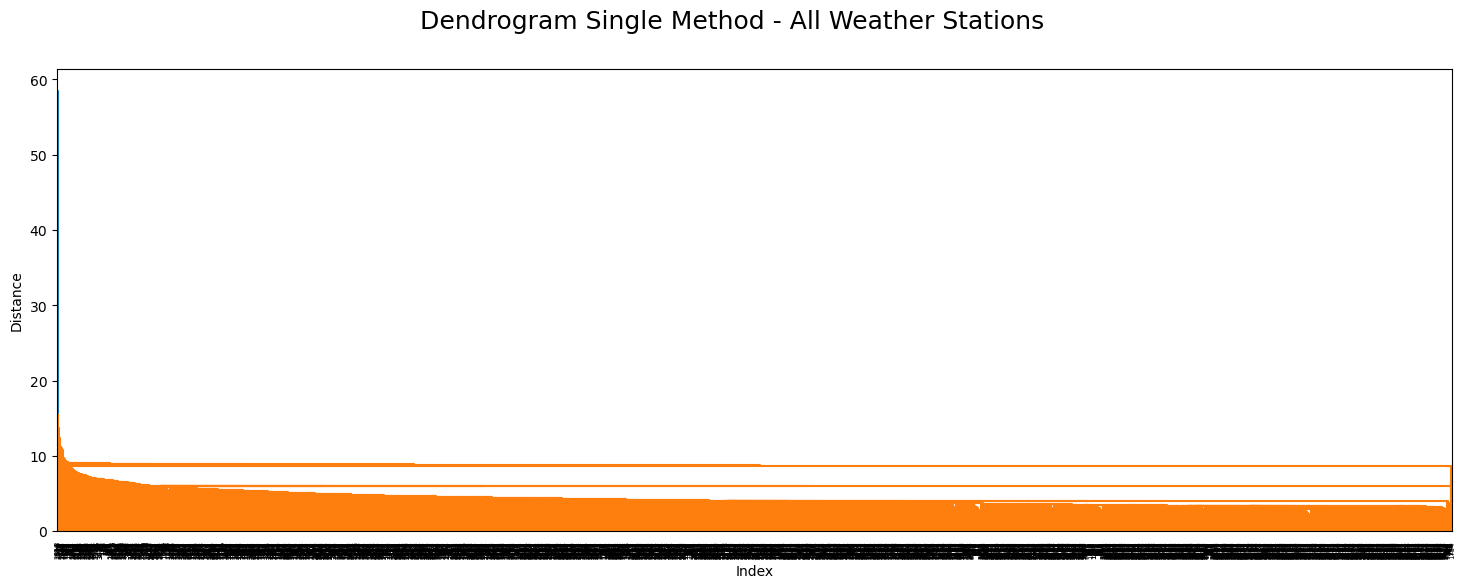

In [25]:
distance_single = linkage(features_scaled, method="single")
plt.figure(figsize=(18,6))
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Single Method - All Weather Stations",fontsize=18)
plt.show()

#### 2. Complete

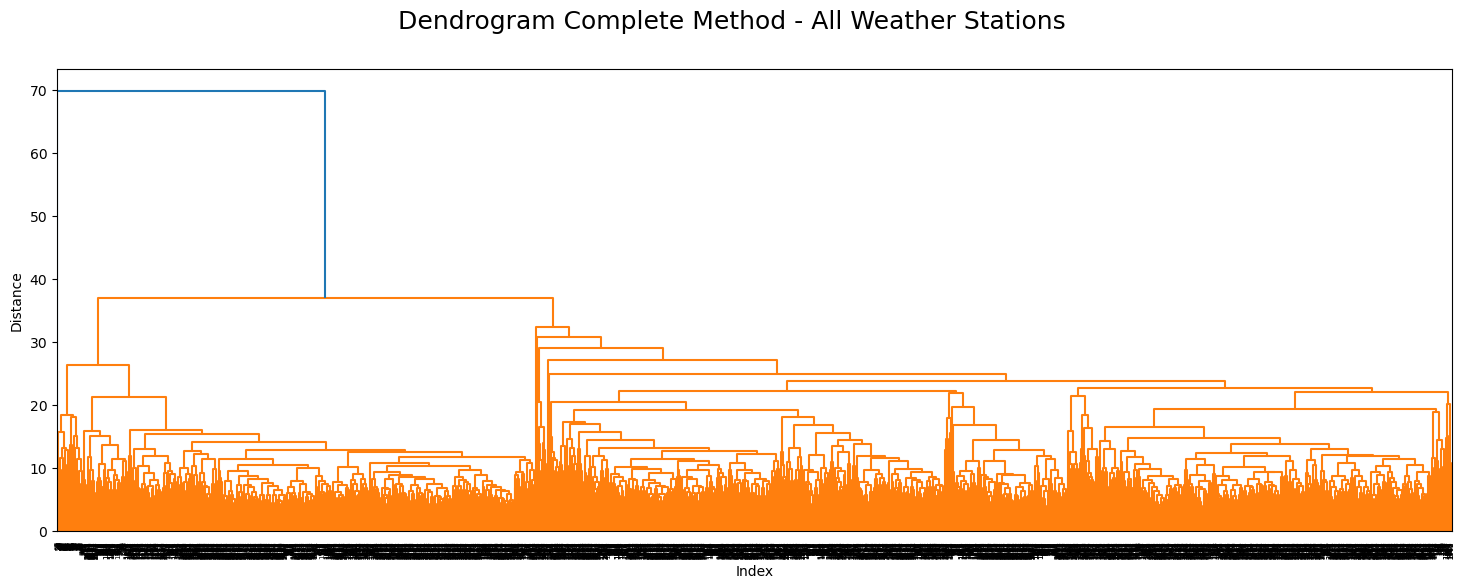

In [27]:
distance_complete = linkage(features_scaled, method="complete")
plt.figure(figsize=(18,6))
dendrogram(distance_complete, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Complete Method - All Weather Stations",fontsize=18)
plt.show()

#### 3. Average

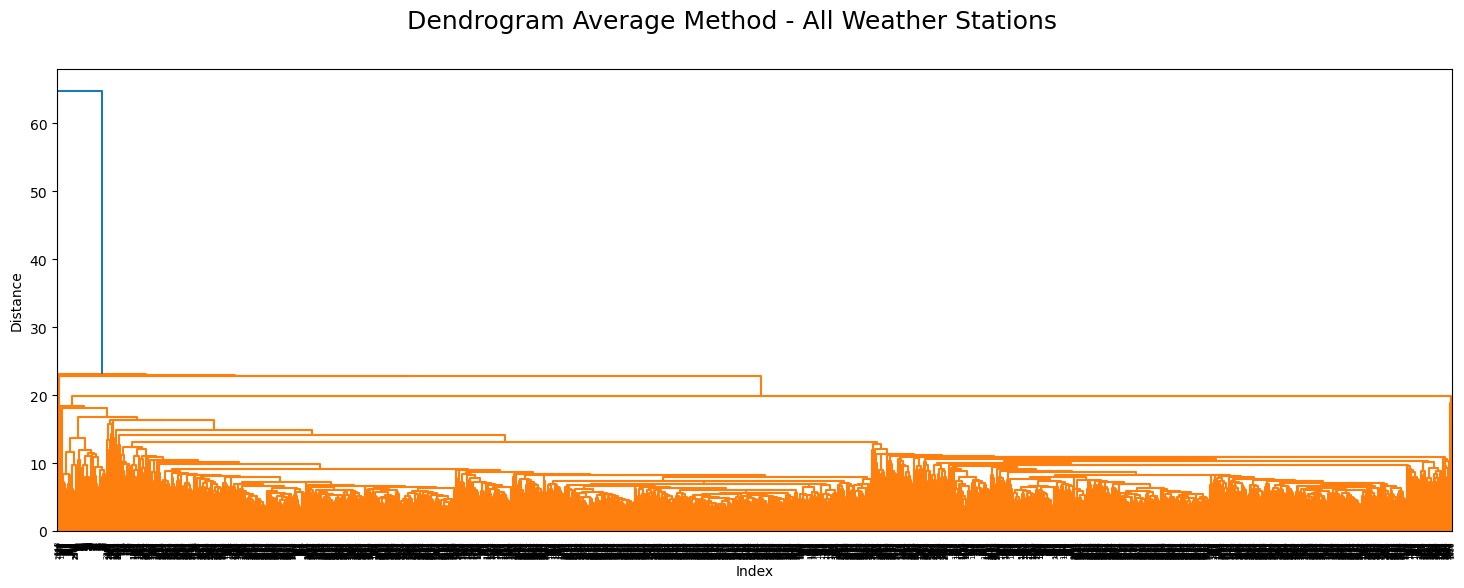

In [29]:
distance_average = linkage(features_scaled, method="average")
plt.figure(figsize=(18,6))
dendrogram(distance_average, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Average Method - All Weather Stations",fontsize=18)
plt.show()

#### 4. Ward

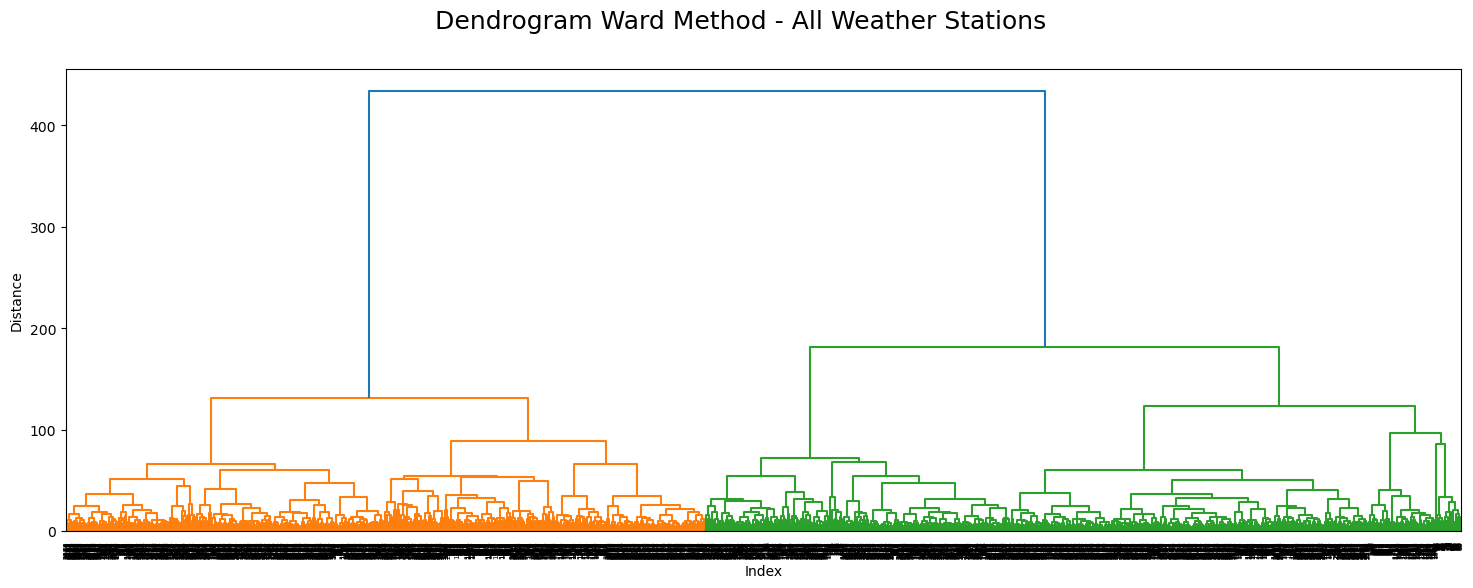

In [31]:
distance_ward = linkage(features_scaled, method="ward")
plt.figure(figsize=(18,6))
dendrogram(distance_ward, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Ward Method - All Weather Stations",fontsize=18)
plt.show()

### Principal Component Analysis

#### Reduce Number of Components

In [34]:
#check number of cols in features_scaled
features_scaled.shape

(3652, 75)

In [35]:
#there are 75 components, 5 for all 15 locations. we can start with 15.
pca = PCA(n_components=15)
principalComponents = pca.fit_transform(features_scaled)

In [36]:
principalComponents

array([[-10.56927206,  -0.44668955,  -7.16171336, ...,   2.71231912,
         -1.48384947,   0.46041306],
       [-12.8782369 ,   0.60826937,  -7.00709415, ...,   1.00018005,
         -2.70779851,  -0.09495318],
       [-13.93342373,   2.11496357,  -4.97807495, ...,   3.26462668,
         -3.47392595,  -0.94691936],
       ...,
       [ -7.52659767,   1.67308015,   1.8847377 , ...,   0.10788429,
          0.1417487 ,  -0.53122391],
       [ -6.13637736,   2.87816029,   1.3601696 , ...,  -0.35354291,
          0.10720244,  -0.33829966],
       [ -6.35160208,   1.09989288,   1.56947371, ...,  -0.22358718,
          0.1759021 ,  -0.37759611]])

In [37]:
#create new dataframe with these principal components
df_pca = pd.DataFrame(principalComponents, columns=['PCA1', 'PCA2', 'PCA3', 'PCA4', 'PCA5', 'PCA6', 'PCA7', 'PCA8', 'PCA9', 'PCA10', 'PCA11', 'PCA12', 'PCA13', 'PCA14', 'PCA15'])

In [38]:
df_pca

,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,PCA8,PCA9,PCA10,PCA11,PCA12,PCA13,PCA14,PCA15
0,-10.569272,-0.446690,-7.161713,-9.075218,5.400148,0.494089,-4.621649,0.571152,-0.353252,0.566872,-0.962148,2.248251,2.712319,-1.483849,0.460413
1,-12.878237,0.608269,-7.007094,-9.992884,6.103118,1.559470,-5.642009,1.203495,-0.099519,0.313468,-1.219422,1.558909,1.000180,-2.707799,-0.094953
2,-13.933424,2.114964,-4.978075,-11.347575,5.146591,1.039283,-4.305253,0.558013,-0.789615,1.359470,-1.591258,-1.632503,3.264627,-3.473926,-0.946919
3,-14.099591,2.252419,-4.410979,-8.543047,4.592105,0.706078,-1.789631,-0.137948,-0.549157,-0.894690,-0.989694,1.983193,0.634021,-1.364676,-0.813625
4,-14.329346,1.245933,-6.152217,-8.873900,3.576875,0.469738,-4.335034,1.364051,0.766623,0.203491,0.415686,0.690737,0.537643,-2.742631,-0.962735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3647,-6.519567,-0.637264,0.224144,1.522349,0.051851,-0.353793,-0.535595,0.201144,-0.987743,0.835296,-0.115755,-0.073349,-0.212038,-0.216558,0.393774
3648,-7.712975,1.443889,1.247096,1.143904,-0.153384,0.033502,-1.093366,-0.641593,-0.107109,0.127566,0.159205,0.120023,0.511035,0.495273,-0.307695
3649,-7.526598,1.673080,1.884738,0.909663,-0.883620,0.550454,-1.489616,-0.515400,-0.879892,-0.116248,-0.258832,0.117836,0.107884,0.141749,-0.531224
3650,-6.136377,2.878160,1.360170,1.003959,-0.951607,0.931135,-0.771701,-0.148669,-0.356170,0.709707,-0.520248,-0.189045,-0.353543,0.107202,-0.338300


In [39]:
#export PCA dataframe as csv
df_pca.to_csv(os.path.join(path, 'weather2010_pca15_scaled.csv'), index=False)

### Classification Methods using Reduced Data

#### 1. Single

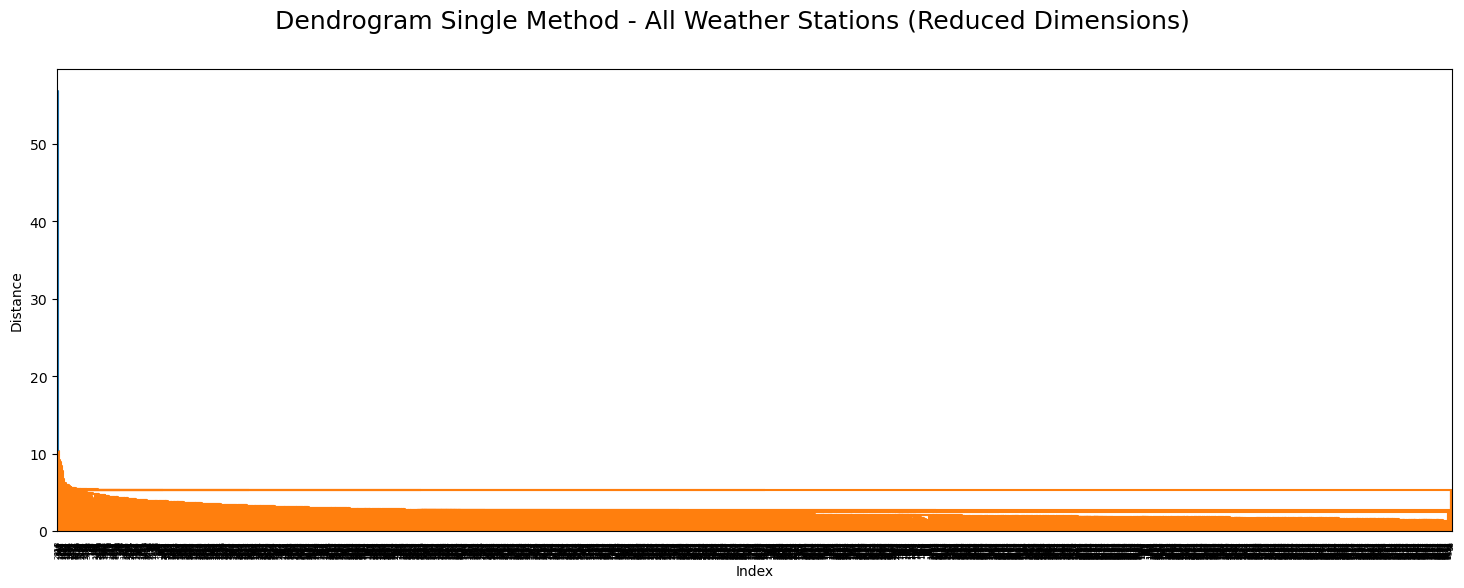

In [42]:
distance_single = linkage(df_pca, method="single")
plt.figure(figsize=(18,6))
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Single Method - All Weather Stations (Reduced Dimensions)",fontsize=18)
plt.show()

#### 2. Complete

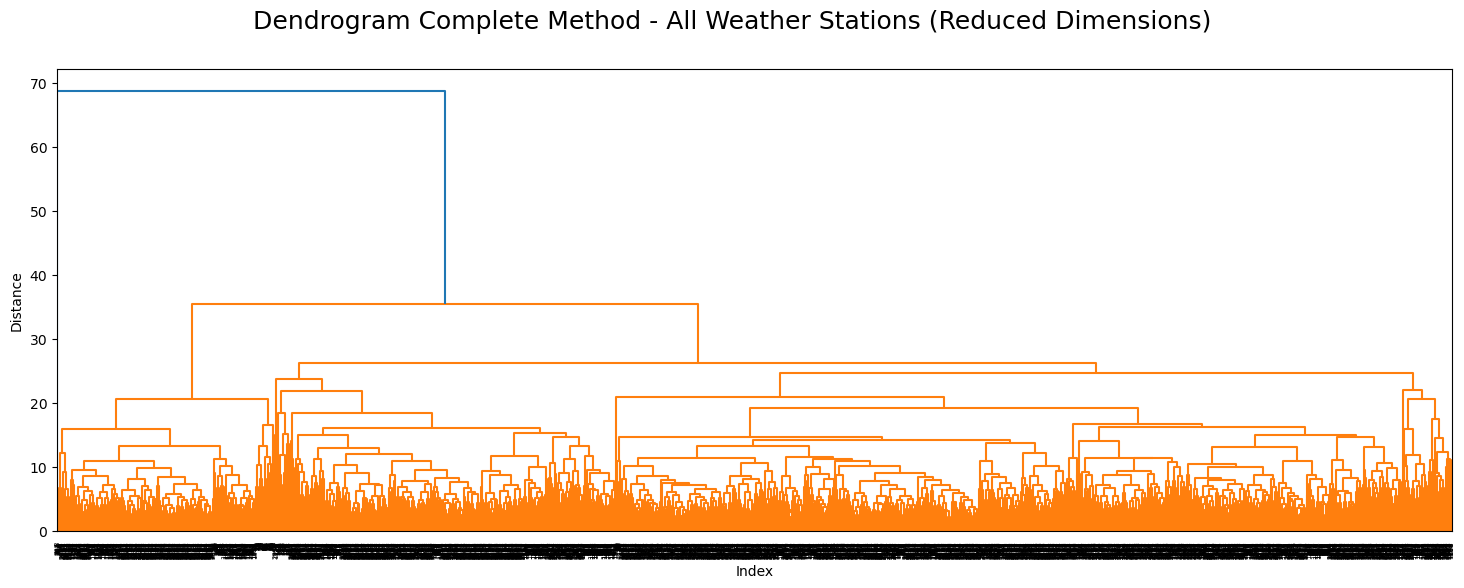

In [44]:
distance_complete = linkage(df_pca, method="complete")
plt.figure(figsize=(18,6))
dendrogram(distance_complete, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Complete Method - All Weather Stations (Reduced Dimensions)",fontsize=18)
plt.show()

#### 3. 

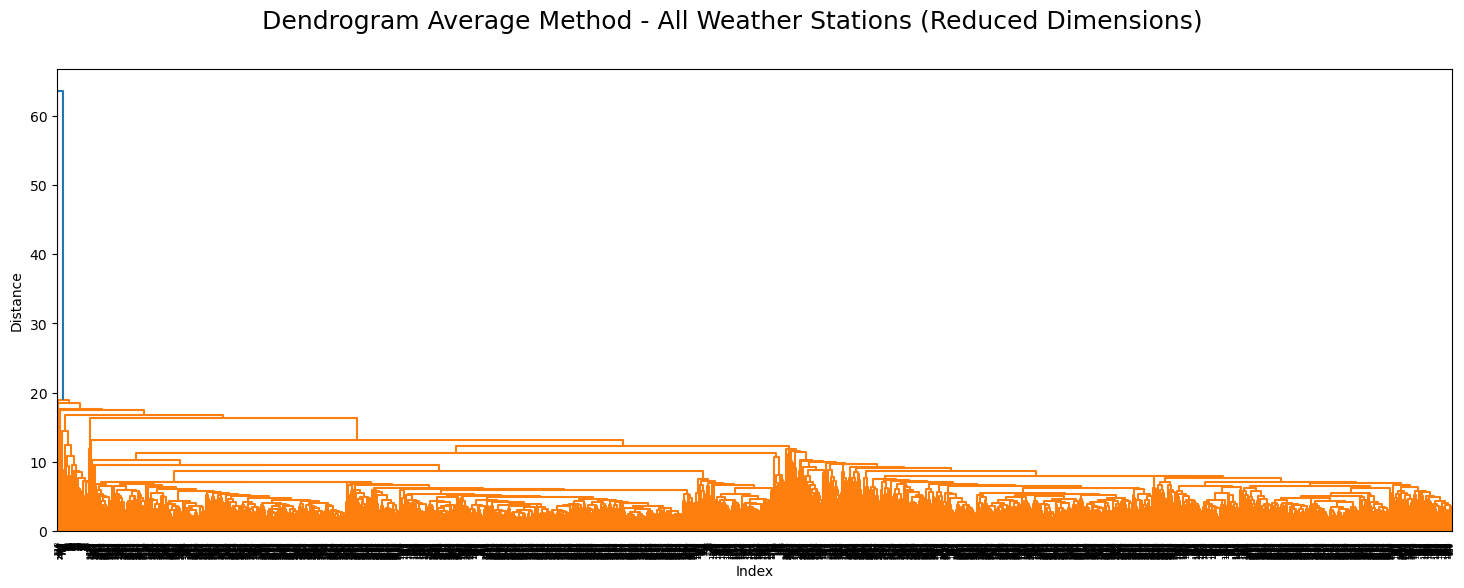

In [46]:
distance_average = linkage(df_pca, method="average")
plt.figure(figsize=(18,6))
dendrogram(distance_average, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Average Method - All Weather Stations (Reduced Dimensions)",fontsize=18)
plt.show()

#### 4. Ward

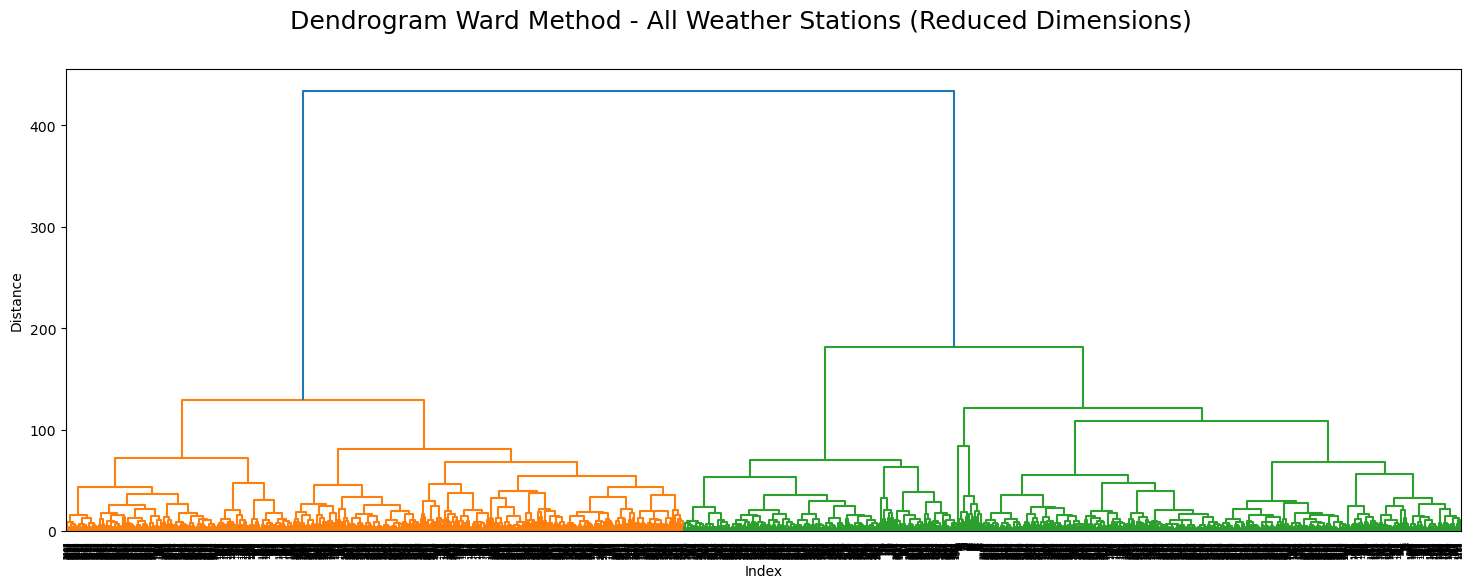

In [48]:
distance_ward = linkage(df_pca, method="ward")
plt.figure(figsize=(18,6))
dendrogram(distance_ward, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Ward Method - All Weather Stations (Reduced Dimensions)",fontsize=18)
plt.show()

#### Compare PCA Reduced Data with 15 Components to Pleasant Weather Data

In [50]:
#add the sum column from pleasant weather to the pca df
df_pca['pleasant_days'] = features_complete['sum']

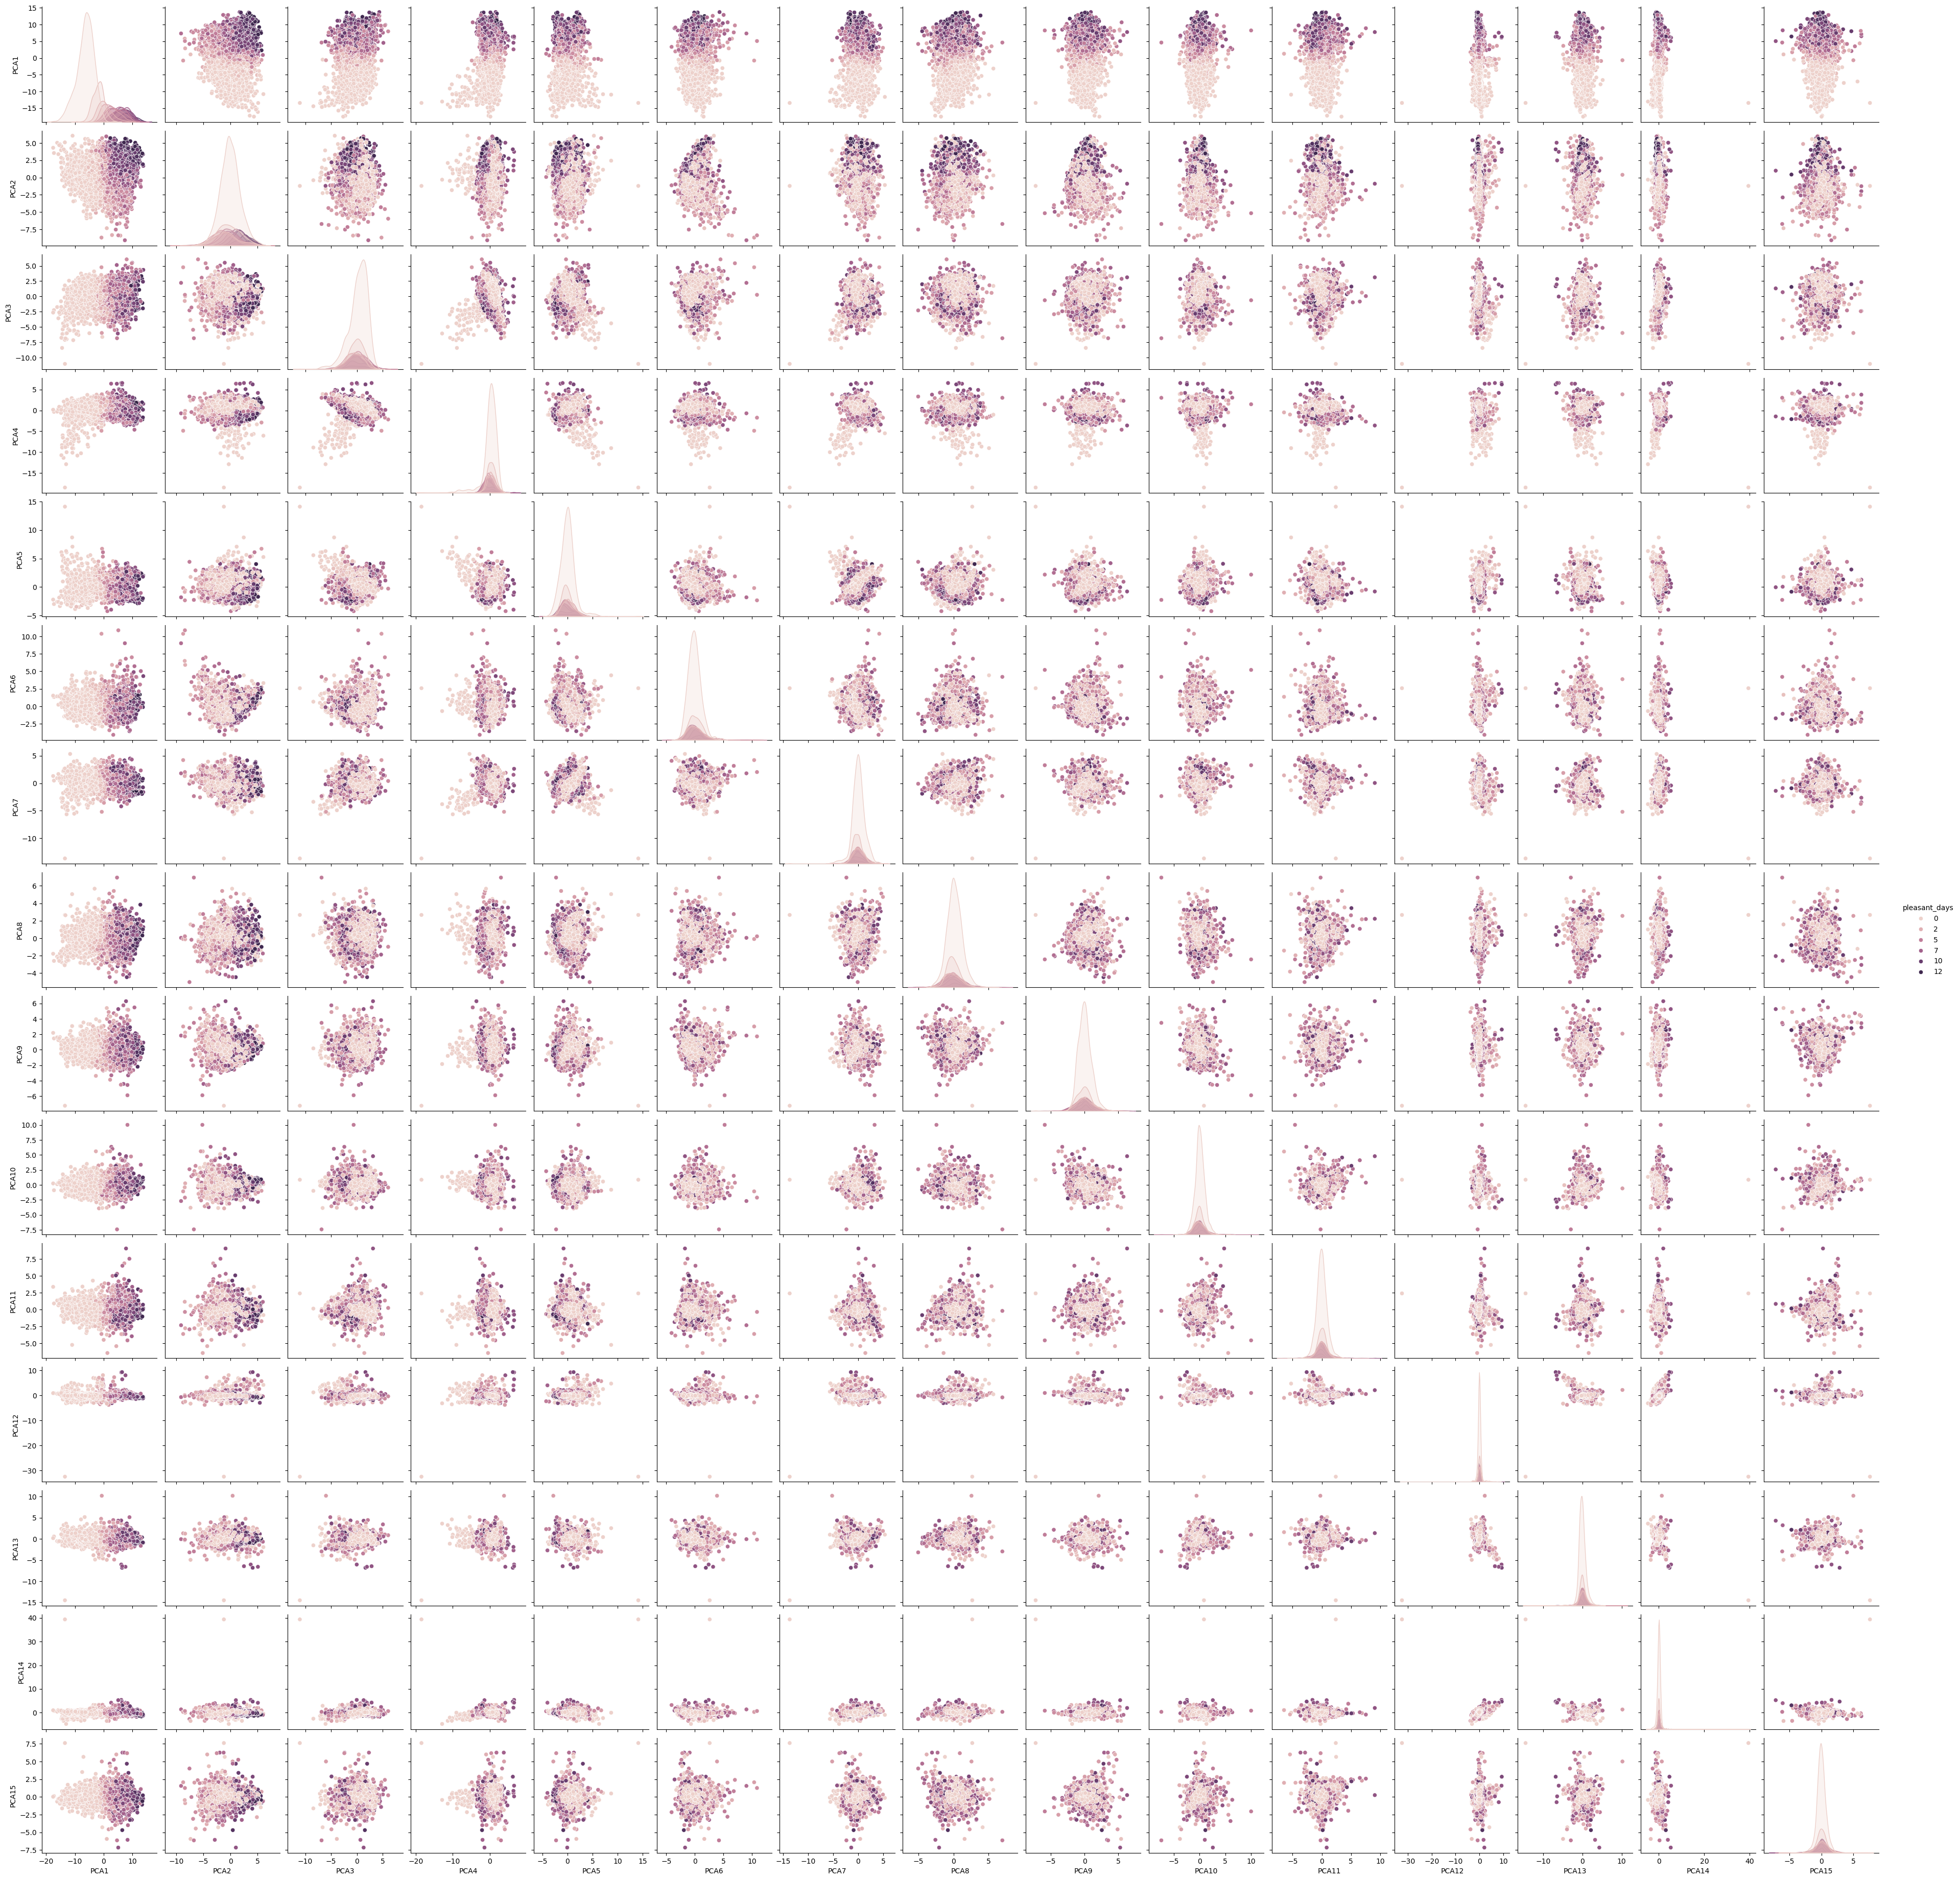

In [51]:
#plot the data points, colour coded by pleasant weather
sns.pairplot(df_pca, hue = 'pleasant_days')
plt.show()

#### Reduce number of components to 5

In [53]:
pca = PCA(n_components=5)
principalComponents = pca.fit_transform(features_scaled)

In [54]:
principalComponents

array([[-10.56927206,  -0.44668955,  -7.16171336,  -9.07521787,
          5.40014794],
       [-12.8782369 ,   0.60826937,  -7.00709415,  -9.99288354,
          6.10311821],
       [-13.93342373,   2.11496357,  -4.97807495, -11.34757466,
          5.14659082],
       ...,
       [ -7.52659767,   1.67308015,   1.8847377 ,   0.90966321,
         -0.88361987],
       [ -6.13637736,   2.87816029,   1.3601696 ,   1.00395896,
         -0.9516066 ],
       [ -6.35160208,   1.09989288,   1.56947371,   0.73013043,
         -0.51963215]])

In [55]:
df_pca5 = pd.DataFrame(principalComponents, columns=['PCA1', 'PCA2', 'PCA3', 'PCA4', 'PCA5'])

In [56]:
df_pca5.to_csv(os.path.join(path, 'weather2010_pca5_scaled.csv'), index=False)

### Classification Methods using Reduced Data (5 Components)

#### 1. Single

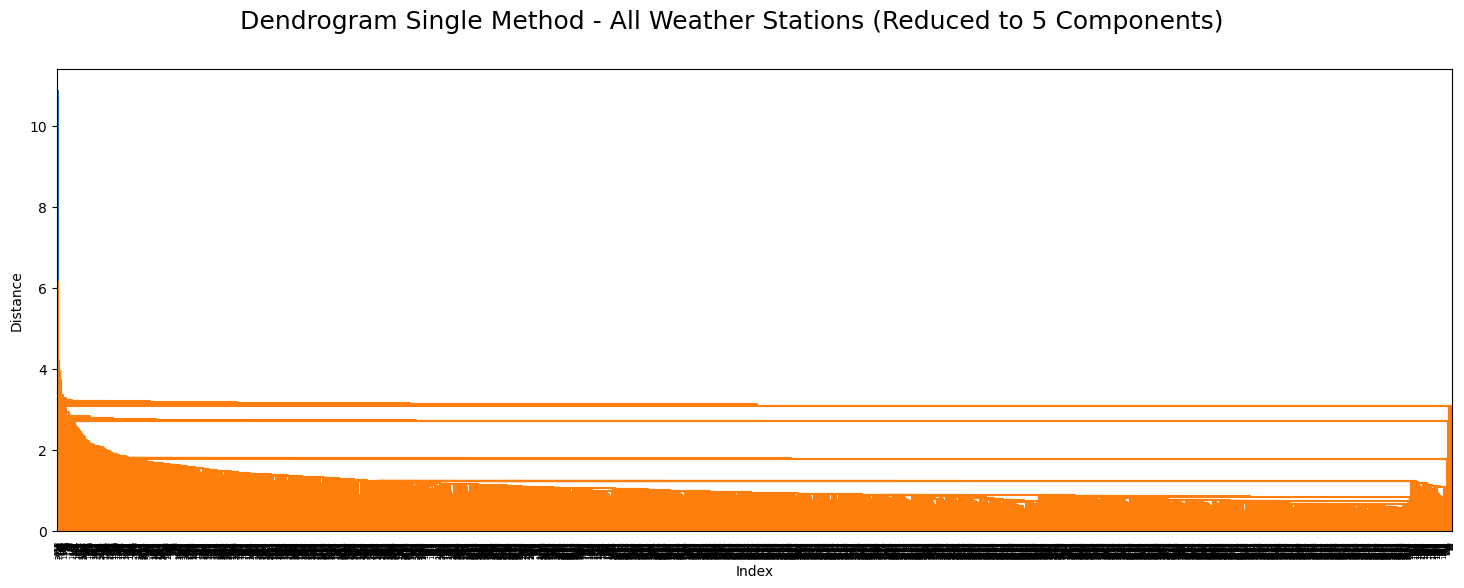

In [59]:
distance_single = linkage(df_pca5, method="single")
plt.figure(figsize=(18,6))
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Single Method - All Weather Stations (Reduced to 5 Components)",fontsize=18)
plt.show()

#### 2. Complete

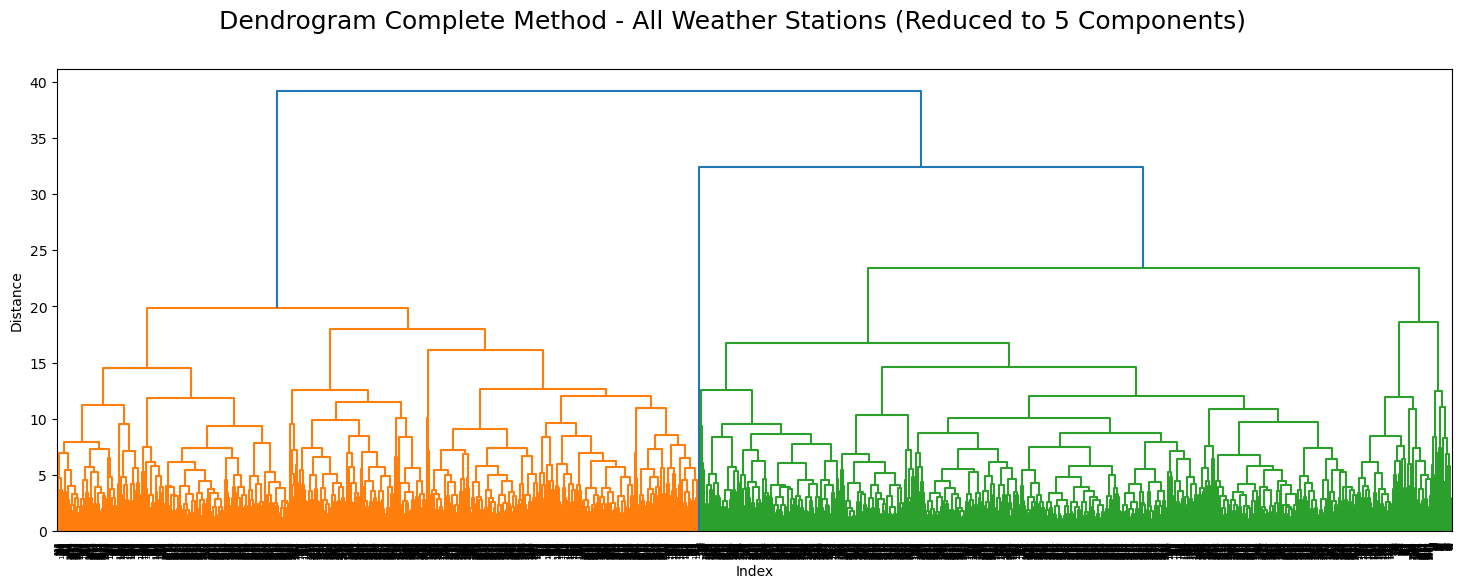

In [61]:
distance_complete = linkage(df_pca5, method="complete")
plt.figure(figsize=(18,6))
dendrogram(distance_complete, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Complete Method - All Weather Stations (Reduced to 5 Components)",fontsize=18)
plt.show()

#### 3. Average

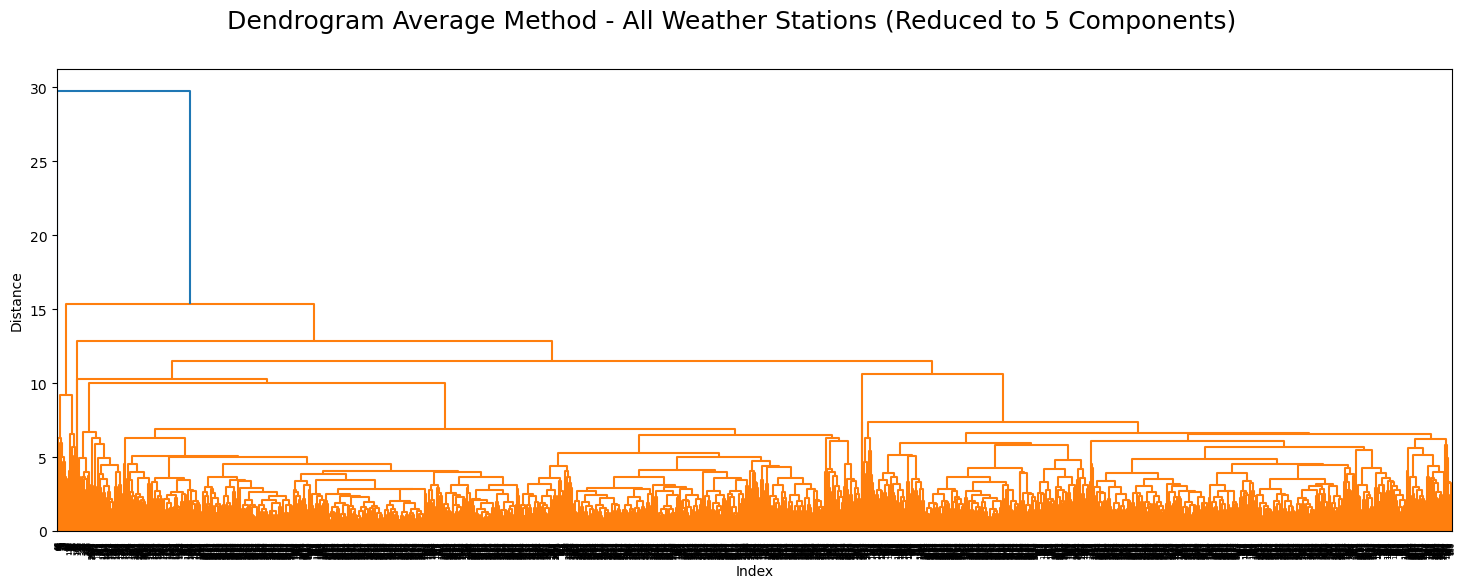

In [63]:
distance_average = linkage(df_pca5, method="average")
plt.figure(figsize=(18,6))
dendrogram(distance_average, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Average Method - All Weather Stations (Reduced to 5 Components)",fontsize=18)
plt.show()

#### 4. Ward

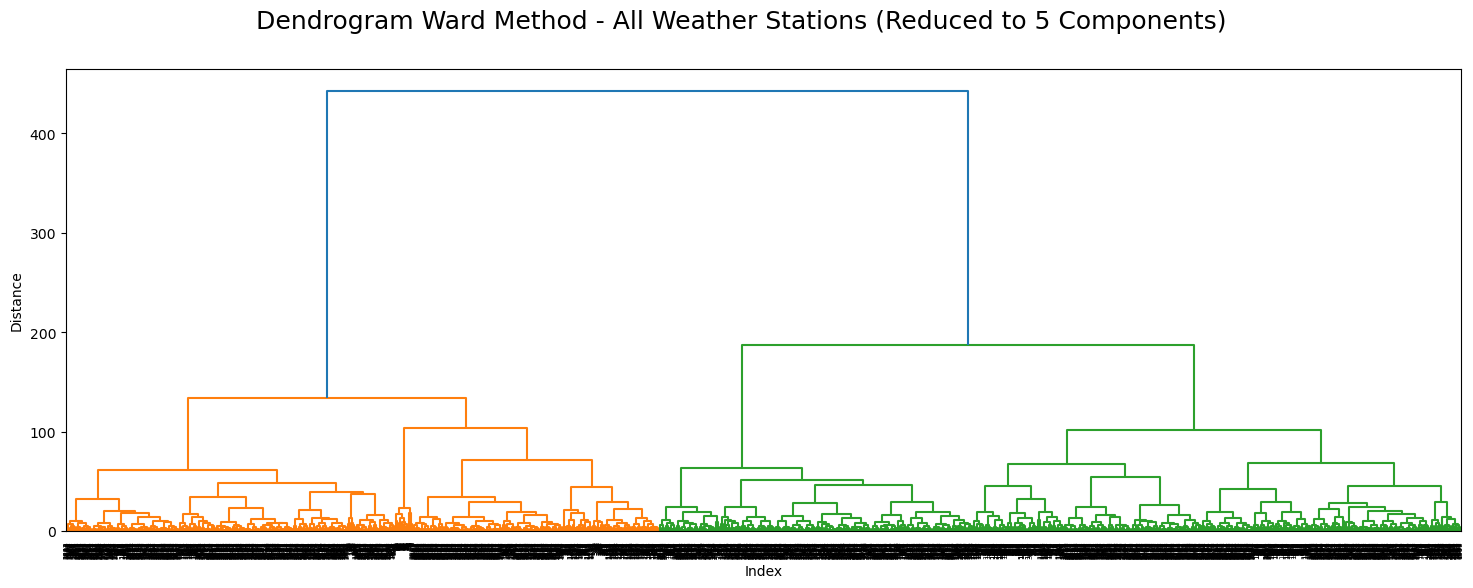

In [65]:
distance_ward = linkage(df_pca5, method="ward")
plt.figure(figsize=(18,6))
dendrogram(distance_ward, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Ward Method - All Weather Stations (Reduced to 5 Components)",fontsize=18)
plt.show()

#### Compare PCA Reduced Data with 5 Components to Pleasant Weather Data

In [67]:
#add the sum column from pleasant weather to the pca df
df_pca5['pleasant_days'] = features_complete['sum']

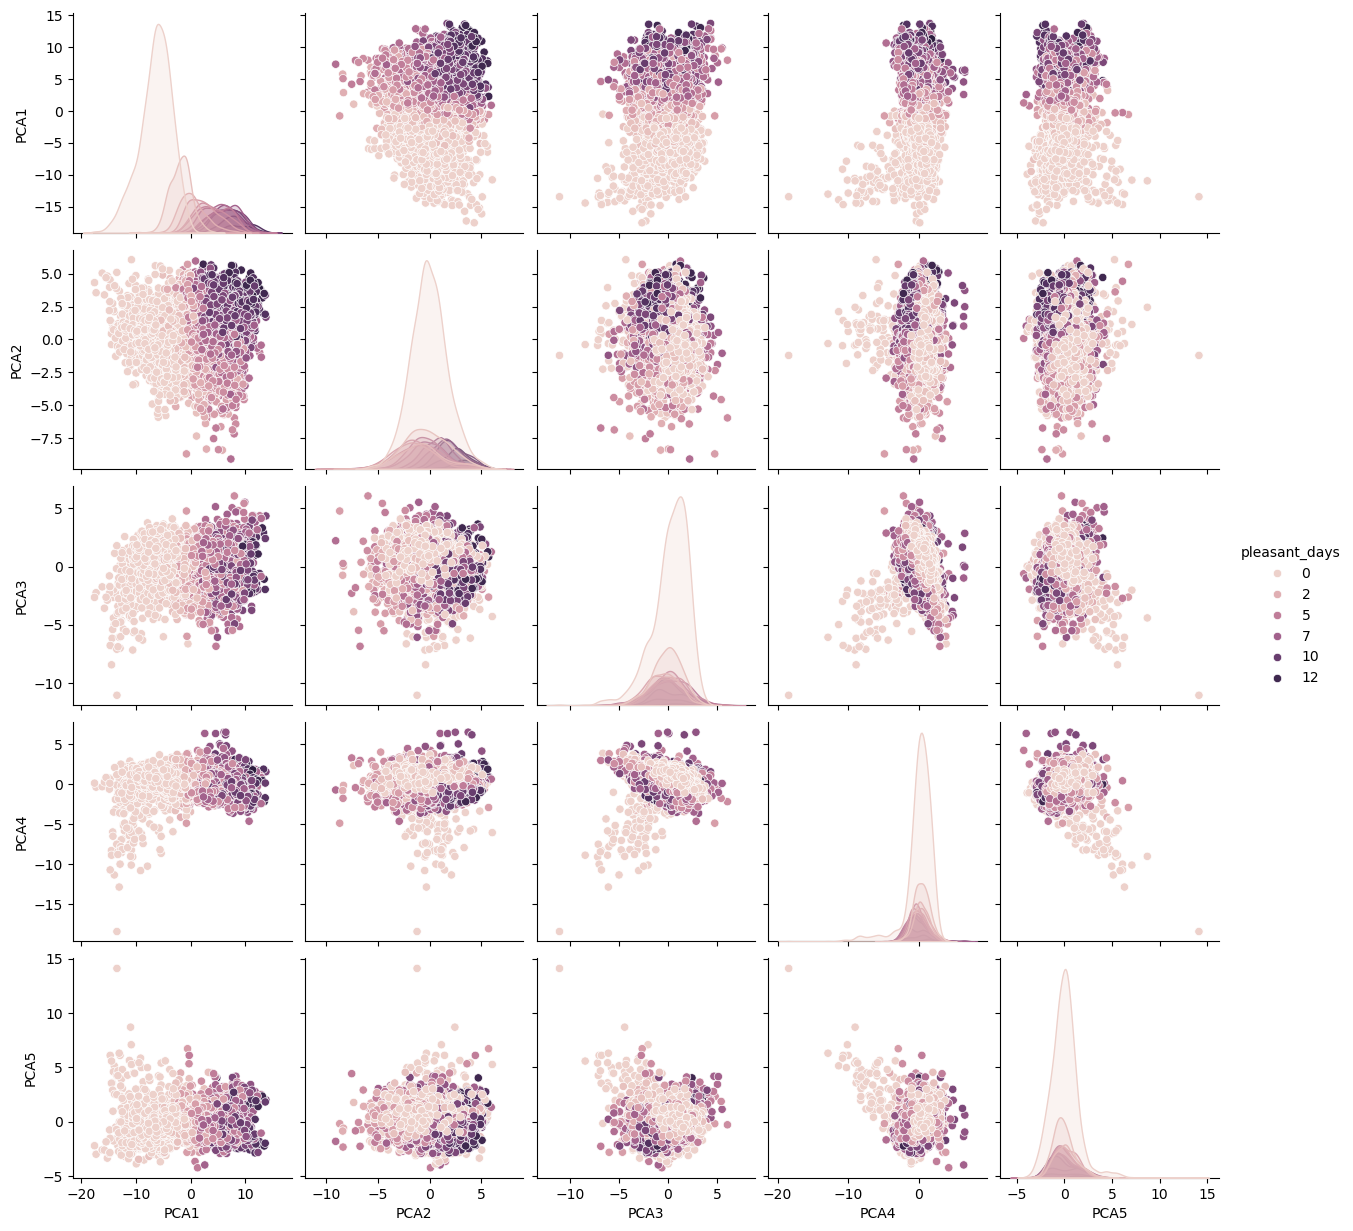

In [68]:
#plot the data points, colour coded by pleasant weather
sns.pairplot(df_pca5, hue = 'pleasant_days')
plt.show()

#### Reduce Components to 2

In [70]:
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(features_scaled)

In [71]:
df_pca2 = pd.DataFrame(principalComponents, columns=['PCA1', 'PCA2'])

In [72]:
df_pca2.to_csv(os.path.join(path, 'weather2010_pca2_scaled.csv'), index=False)

#### Rerun Classification Methods With Data Reduced to 2 Components

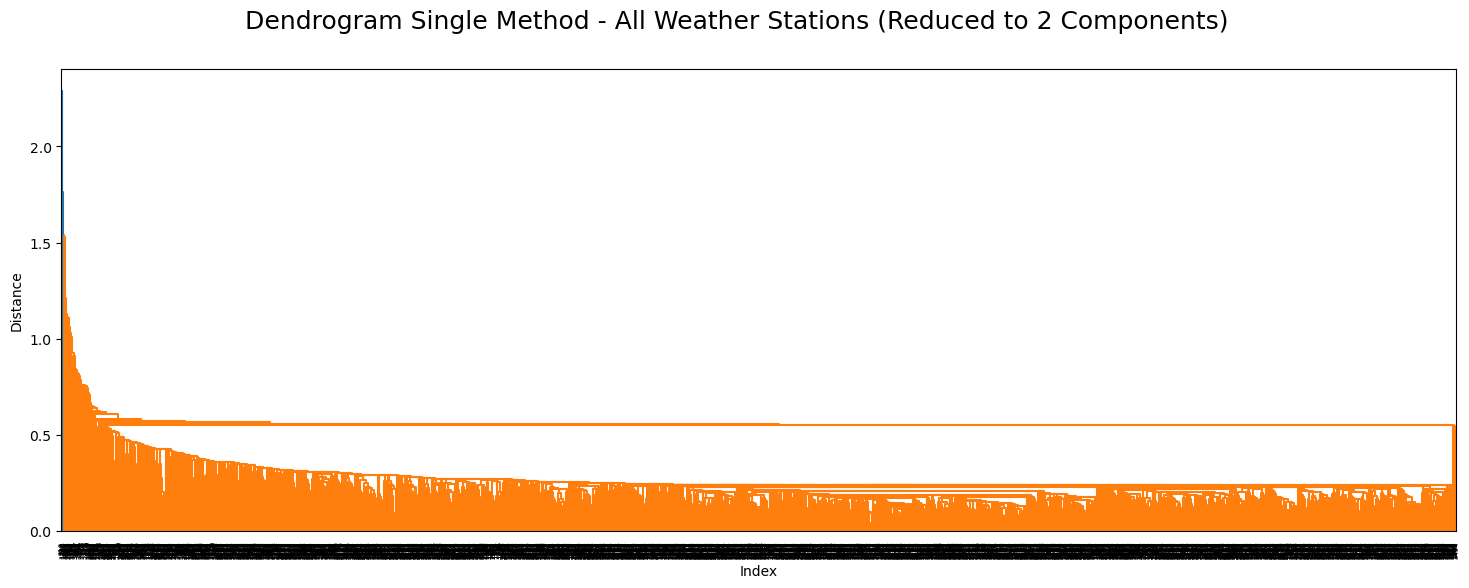

In [74]:
distance_single = linkage(df_pca2, method="single")
plt.figure(figsize=(18,6))
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Single Method - All Weather Stations (Reduced to 2 Components)",fontsize=18)
plt.show()

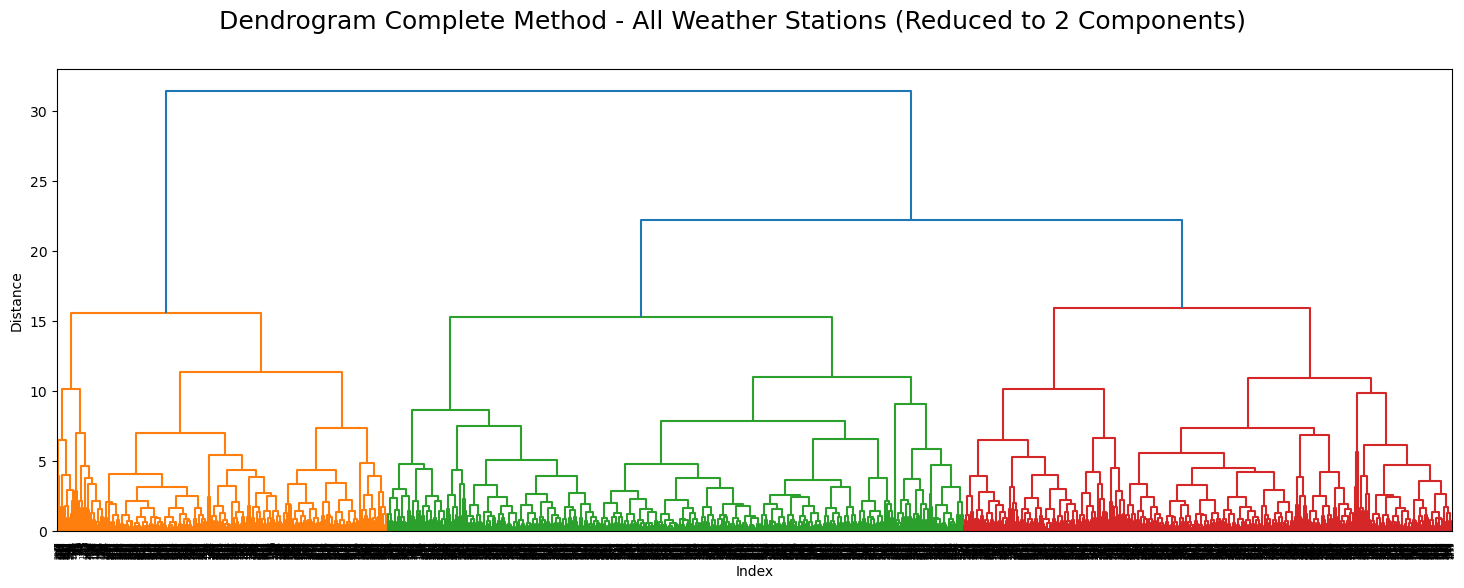

In [75]:
distance_complete = linkage(df_pca2, method="complete")
plt.figure(figsize=(18,6))
dendrogram(distance_complete, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Complete Method - All Weather Stations (Reduced to 2 Components)",fontsize=18)
plt.show()

#### 3. Average

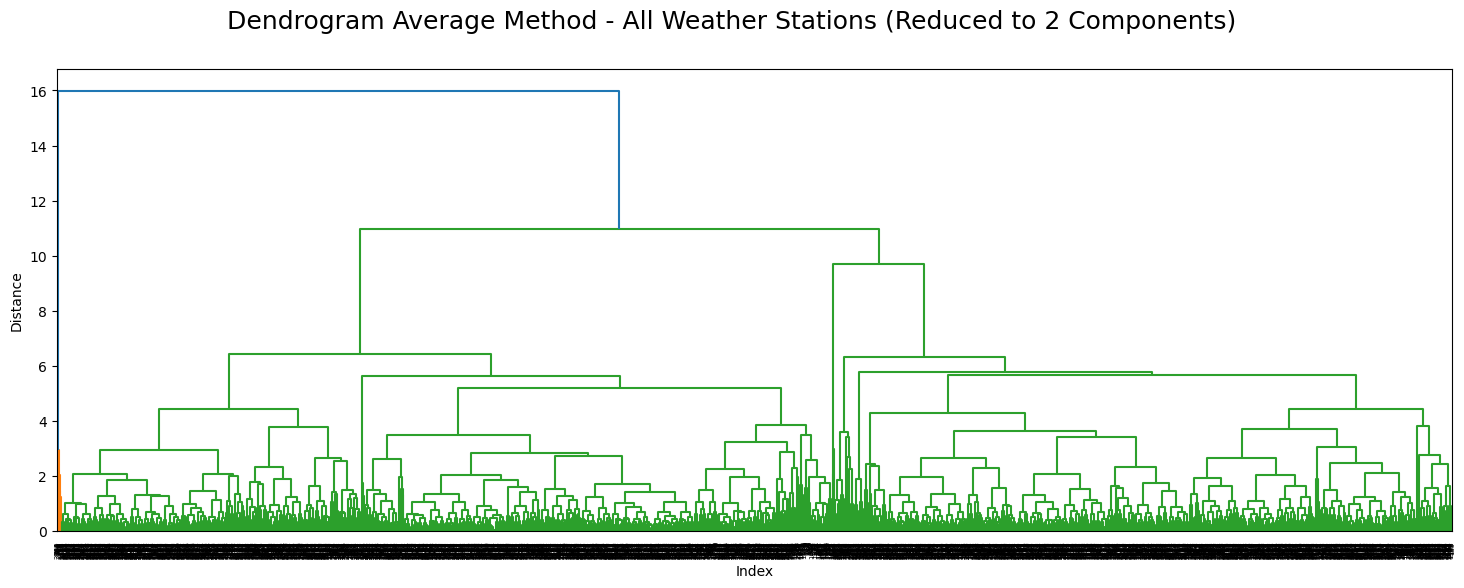

In [77]:
distance_average = linkage(df_pca2, method="average")
plt.figure(figsize=(18,6))
dendrogram(distance_average, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Average Method - All Weather Stations (Reduced to 2 Components)",fontsize=18)
plt.show()

#### 4. Ward

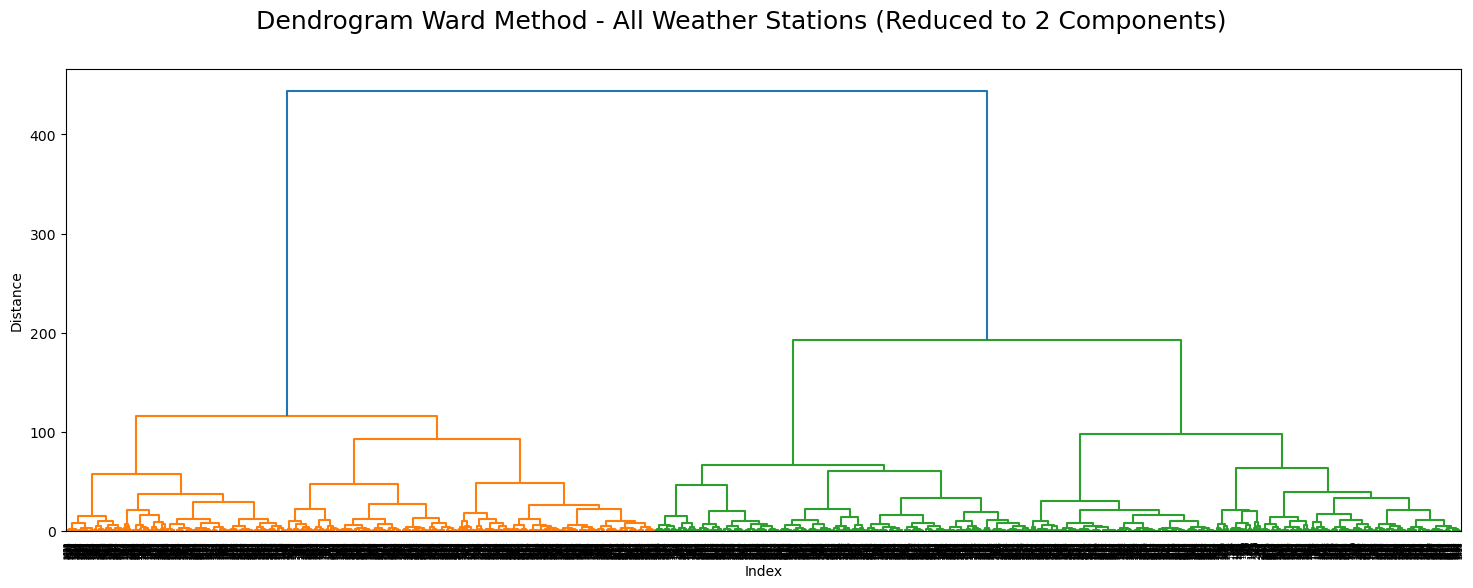

In [79]:
distance_ward = linkage(df_pca2, method="ward")
plt.figure(figsize=(18,6))
dendrogram(distance_ward, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Ward Method - All Weather Stations (Reduced to 2 Components)",fontsize=18)
plt.show()

#### Comparing PCA Reduced Data with 2 Components to Pleasant Weather Data

In [81]:
#add the sum column from pleasant weather to the pca df
df_pca2['pleasant_days'] = features_complete['sum']

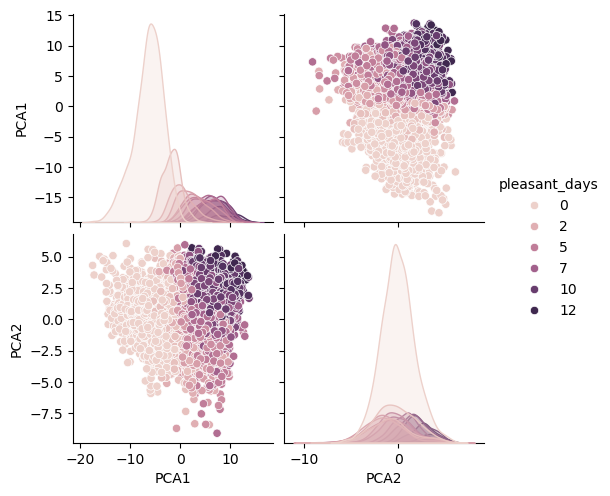

In [82]:
#plot the data points, colour coded by pleasant weather
sns.pairplot(df_pca2, hue = 'pleasant_days')
plt.show()